# 03 — Customer Segmentation: RFM Analysis

**Project:** E-Commerce Customer & Revenue Analytics

**Business question this notebook contributes to:** which customers are most valuable, and how concentrated is revenue among them?

**Purpose of this notebook:** score every customer on **R**ecency, **F**requency, and **M**onetary value, then group them into named segments (Champions, Loyal, Potential Loyalists, At Risk, Lost) that the business can act on directly — e.g. who to reward, who to win back, who's at risk of churning.

1. Build customer-level Recency / Frequency / Monetary metrics
2. Look at each metric's distribution before scoring it
3. Score R, F, M on a 1–5 scale and document exactly how
4. Map R/F scores to 5 named segments, with the rule table spelled out
5. Segment summary — size and revenue contribution per segment (customer concentration)
6. Validation asserts
7. Save `customer_rfm.csv`
8. Summary of observations

**Input:** `data/processed/fact_sales_completed.csv` — same validated, Completed-only fact table used in `01` and `02`.

**Scope note:** only the 267 customers with at least one Completed order are scored here — the 33 customers with zero Completed orders (out of 300 total in `customers.csv`) have no purchase history to compute Recency/Frequency/Monetary from, so they can't be meaningfully segmented by this method.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (10, 5)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

fact_sales = pd.read_csv(
    DATA_PROCESSED / "fact_sales_completed.csv",
    parse_dates=["order_date", "order_month", "signup_date"],
)
print("fact_sales_completed shape:", fact_sales.shape)
print("distinct customers with a Completed order:", fact_sales["customer_id"].nunique())

fact_sales_completed shape: (1625, 16)
distinct customers with a Completed order: 267


## 1. Build customer-level RFM metrics

**Snapshot date:** since this dataset doesn't extend into an actual "today," Recency is measured against the day *after* the most recent Completed order in the data — a standard convention that treats the dataset's own latest date as "now."

- **Recency** = days between the snapshot date and each customer's most recent Completed order (lower = more recently active)
- **Frequency** = number of distinct Completed orders
- **Monetary** = total revenue from Completed orders

In [2]:
snapshot_date = fact_sales["order_date"].max() + pd.Timedelta(days=1)
print("Snapshot date:", snapshot_date.date())

rfm = fact_sales.groupby("customer_id").agg(
    recency=("order_date", lambda s: (snapshot_date - s.max()).days),
    frequency=("order_id", "nunique"),
    monetary=("revenue", "sum"),
).reset_index()

print("Customers scored:", len(rfm))
rfm.head()

Snapshot date: 2024-12-31
Customers scored: 267


,customer_id,recency,frequency,monetary
0,1,9,8,2632
1,2,246,1,720
2,3,40,1,180
3,4,81,4,774
4,5,36,6,2465


## 2. Raw metric distributions

,recency,frequency,monetary
count,267.0,267.0,267.0
mean,118.6,2.6,1165.2
std,98.2,1.5,834.5
min,1.0,1.0,12.0
25%,41.0,1.0,542.5
50%,82.0,2.0,980.0
75%,191.5,3.0,1622.0
max,365.0,8.0,5048.0


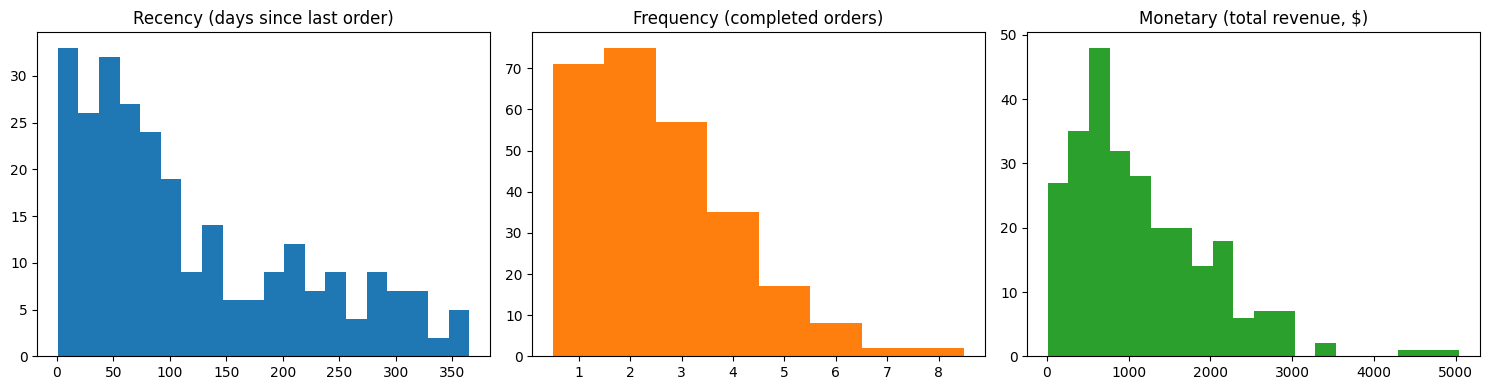

Frequency value counts (small integer range — informs the scoring choice below):
frequency
1    71
2    75
3    57
4    35
5    17
6     8
7     2
8     2
Name: count, dtype: int64


In [3]:
display(rfm[["recency", "frequency", "monetary"]].describe().round(1))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(rfm["recency"], bins=20, color="#1f77b4")
axes[0].set_title("Recency (days since last order)")
axes[1].hist(rfm["frequency"], bins=range(1, 10), color="#ff7f0e", align="left")
axes[1].set_title("Frequency (completed orders)")
axes[2].hist(rfm["monetary"], bins=20, color="#2ca02c")
axes[2].set_title("Monetary (total revenue, $)")
fig.tight_layout()
fig.savefig(FIGURES / "08_rfm_distributions.png", dpi=150)
plt.show()

print("Frequency value counts (small integer range — informs the scoring choice below):")
print(rfm["frequency"].value_counts().sort_index())

## 3. Scoring R, F, M on a 1–5 scale

**Recency and Monetary** are scored with `pd.qcut` — split into 5 equal-sized groups (quintiles), since both have enough distinct values (168 and 252 respectively, out of 267 customers) for that to work cleanly. Recency's labels are assigned in *reverse* (`[5, 4, 3, 2, 1]`) so a **low** day-count (recently active) gets a **high** score.

**Frequency** is scored with fixed thresholds instead of quantiles. It only takes integer values 1–8, and a plain `pd.qcut` on it collapses into just 4 uneven groups here (frequency 1 and 2 alone account for 146 of 267 customers, so the bottom two theoretical quintiles merge into one). Since each additional order is already a meaningful, interpretable unit, mapping order count directly to score avoids that collapsing and is easier to explain: 1 order → F1, 2 → F2, 3 → F3, 4 → F4, 5+ → F5.

In [4]:
rfm["R"] = pd.qcut(rfm["recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["M"] = pd.qcut(rfm["monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm["F"] = np.select(
    [rfm["frequency"] == 1, rfm["frequency"] == 2, rfm["frequency"] == 3, rfm["frequency"] == 4],
    [1, 2, 3, 4],
    default=5,
)

rfm["rfm_score"] = rfm["R"] + rfm["F"] + rfm["M"]

print("Score group sizes:")
for col in ["R", "F", "M"]:
    print(f"\n{col}:")
    print(rfm[col].value_counts().sort_index())

rfm.head()

Score group sizes:

R:
R
1    52
2    55
3    53
4    52
5    55
Name: count, dtype: int64

F:
F
1    71
2    75
3    57
4    35
5    29
Name: count, dtype: int64

M:
M
1    54
2    53
3    53
4    53
5    54
Name: count, dtype: int64


,customer_id,recency,frequency,monetary,R,M,F,rfm_score
0,1,9,8,2632,5,5,5,15
1,2,246,1,720,1,2,1,4
2,3,40,1,180,4,1,1,6
3,4,81,4,774,3,3,4,10
4,5,36,6,2465,4,5,5,14


## 4. Mapping R/F scores to named segments

Five segments, defined from the R and F scores only (Monetary is used afterward to measure each segment's revenue, not to define segment membership — keeping the segment logic to two axes makes the rule table easy to state and easy to defend). The rules are evaluated in order and are exhaustive over every possible R×F combination (25 cells):

| Segment | Rule | Meaning |
|---|---|---|
| **Champions** | R = 5 and F = 5 | Bought very recently *and* most often — the best customers by both measures |
| **Loyal** | R ≥ 3 and F ≥ 3 (not Champions) | Recently active and reasonably frequent, just short of the top tier |
| **Potential Loyalists** | R ≥ 3 and F < 3 | Recently active, but haven't bought often yet — candidates to grow into Loyal |
| **At Risk** | R < 3 and F ≥ 3 | Used to buy often, but haven't ordered recently — the clearest win-back target |
| **Lost** | R < 3 and F < 3 | Neither recent nor frequent |

In [5]:
def assign_segment(row):
    r, f = row["R"], row["F"]
    if r == 5 and f == 5:
        return "Champions"
    if r >= 3 and f >= 3:
        return "Loyal"
    if r >= 3 and f < 3:
        return "Potential Loyalists"
    if r < 3 and f >= 3:
        return "At Risk"
    return "Lost"

rfm["segment"] = rfm.apply(assign_segment, axis=1)

segment_order = ["Champions", "Loyal", "Potential Loyalists", "At Risk", "Lost"]
print("Every R\u00d7F cell covered by exactly one segment:", rfm["segment"].isin(segment_order).all())
rfm["segment"].value_counts().reindex(segment_order)

Every R×F cell covered by exactly one segment: True


segment
Champions              10
Loyal                  80
Potential Loyalists    70
At Risk                31
Lost                   76
Name: count, dtype: int64

## 5. Segment summary — size and revenue contribution

This is where customer concentration shows up: how much of total revenue comes from how few customers.

,customers,pct_of_customers,total_revenue,pct_of_revenue,avg_revenue_per_customer,avg_recency_days,avg_frequency
segment,,,,,,,
Champions,10,3.7,27581,8.9,2758.10,16.3,5.80
Loyal,80,30.0,131473,42.3,1643.41,50.7,3.78
Potential Loyalists,70,26.2,52008,16.7,742.97,53.9,1.66
At Risk,31,11.6,50578,16.3,1631.55,178.5,3.68
Lost,76,28.5,49471,15.9,650.93,238.6,1.38


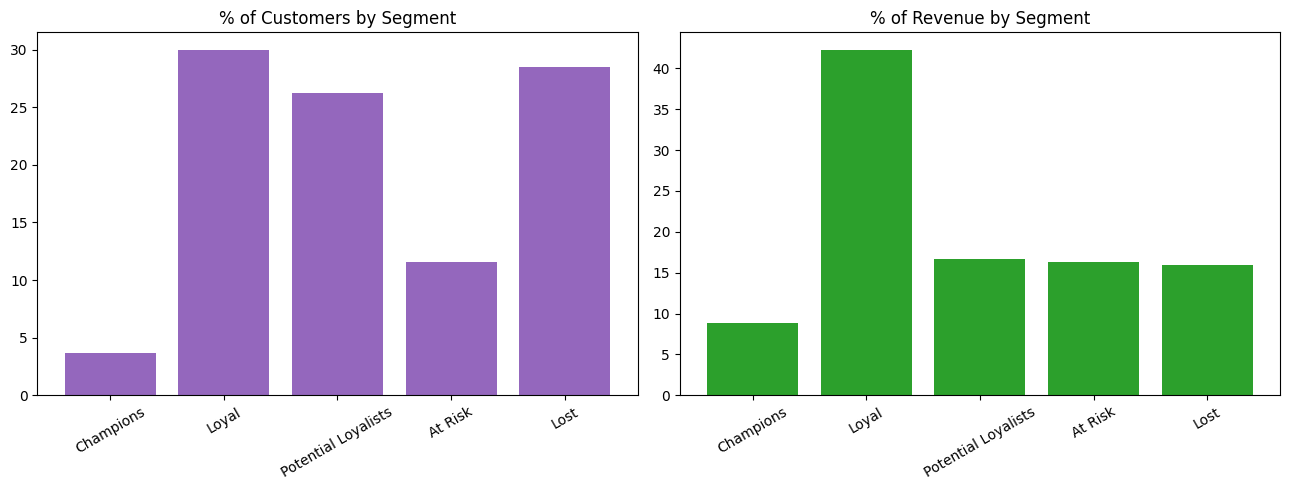

In [6]:
segment_summary = rfm.groupby("segment").agg(
    customers=("customer_id", "count"),
    total_revenue=("monetary", "sum"),
    avg_revenue_per_customer=("monetary", "mean"),
    avg_recency_days=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
).reindex(segment_order)

segment_summary["pct_of_customers"] = (segment_summary["customers"] / len(rfm) * 100).round(1)
segment_summary["pct_of_revenue"] = (segment_summary["total_revenue"] / rfm["monetary"].sum() * 100).round(1)
segment_summary["avg_revenue_per_customer"] = segment_summary["avg_revenue_per_customer"].round(2)
segment_summary["avg_recency_days"] = segment_summary["avg_recency_days"].round(1)
segment_summary["avg_frequency"] = segment_summary["avg_frequency"].round(2)

display(segment_summary[[
    "customers", "pct_of_customers", "total_revenue", "pct_of_revenue",
    "avg_revenue_per_customer", "avg_recency_days", "avg_frequency",
]])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(segment_summary.index, segment_summary["pct_of_customers"], color="#9467bd")
axes[0].set_title("% of Customers by Segment")
axes[0].tick_params(axis="x", rotation=30)
axes[1].bar(segment_summary.index, segment_summary["pct_of_revenue"], color="#2ca02c")
axes[1].set_title("% of Revenue by Segment")
axes[1].tick_params(axis="x", rotation=30)
fig.tight_layout()
fig.savefig(FIGURES / "09_rfm_segment_summary.png", dpi=150)
plt.show()

## 6. Validation asserts

In [7]:
assert rfm["customer_id"].is_unique, "One row per customer expected"
assert rfm[["R", "F", "M"]].isnull().sum().sum() == 0, "R/F/M scores must not be null"
assert rfm["R"].between(1, 5).all() and rfm["F"].between(1, 5).all() and rfm["M"].between(1, 5).all(), \
    "R/F/M scores must be in 1-5"
assert rfm["segment"].isin(segment_order).all(), "Every customer must map to one of the 5 named segments"
assert segment_summary["customers"].sum() == len(rfm), "Segment counts must sum to total scored customers"
assert abs(segment_summary["pct_of_revenue"].sum() - 100) < 0.2, "Revenue share must sum to ~100%"

print("All validation checks passed.")

All validation checks passed.


## 7. Save `customer_rfm.csv`

In [8]:
rfm_out = rfm[[
    "customer_id", "recency", "frequency", "monetary",
    "R", "F", "M", "rfm_score", "segment",
]].sort_values("customer_id")

rfm_out.to_csv(DATA_PROCESSED / "customer_rfm.csv", index=False)
print("Saved:", DATA_PROCESSED / "customer_rfm.csv", rfm_out.shape)

Saved: /Users/yvonne/Desktop/E-commerce Analytics/data/processed/customer_rfm.csv (267, 9)


## 8. Summary of observations

- **Revenue is concentrated in the top two segments.** Champions + Loyal make up just 33.7% of scored customers (90 of 267) but generate 51.2% of revenue ($159,054 of $311,111). Champions alone (10 customers, 3.7%) average $2,758 each — nearly double any other segment's average.
- **At Risk is the segment most worth prioritizing for win-back.** It's small (31 customers, 11.6%) but carries the second-highest average revenue per customer ($1,631.55, close to Champions' $2,758.10) — these were high-value, fairly frequent buyers (avg. 3.68 orders) who've now gone quiet for an average of **178.5 days** (~6 months). Losing them permanently would cost meaningfully more per customer than losing an average Lost customer.
- **Potential Loyalists are a large, low-frequency group with room to grow.** 70 customers (26.2%) are recently active (avg. recency 53.9 days) but have only ordered ~1.7 times on average, contributing a modest 16.7% of revenue. A second-purchase incentive or onboarding nudge targeted at this group has a large addressable base to work with.
- **Lost is the largest segment by customer count (76, 28.5%) but the smallest opportunity.** Average recency is 238.6 days (~8 months) and average revenue per customer ($650.93) is the lowest of all five segments — reactivation spend is likely better directed at At Risk first.
- This directly answers the \"customer concentration\" question from the project's business objective: roughly a third of customers drive about half of revenue, and the segment sizes here (Loyal and Lost both similarly large, ~28-30% each) show the customer base is fairly bimodal — a solid loyal core and a comparably sized disengaged group, without a huge middle.